First 5 rows:
   PassengerId  Survived  Pclass              Name   Sex   Age  SibSp  Parch  \
0            1         1       3   Noah Anderson 1  male  15.7      0      0   
1            2         1       2      Liam Brown 2  male   NaN      2      1   
2            3         0       3   Olivia Thomas 3  male  13.2      0      1   
3            4         0       3     Emma Wilson 4  male  26.0      0      0   
4            5         0       1  Isabella Clark 5  male   6.3      0      0   

     Ticket    Fare Cabin Embarked  
0  PC-46133    7.57   NaN        S  
1  PC-72465   21.97   NaN        Q  
2  PC-87092   11.42  G143        Q  
3   A-80086   10.11   NaN        S  
4  PC-59083  111.34   NaN        S  

Dataset Shape:
(1010, 12)

Duplicate rows: 10

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            130
SibSp            0
Parch            0
Ticket           0
Fare             5
Cabin          728
Embarked  

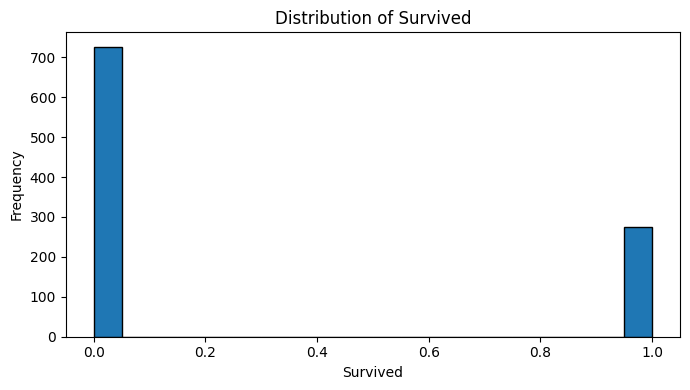

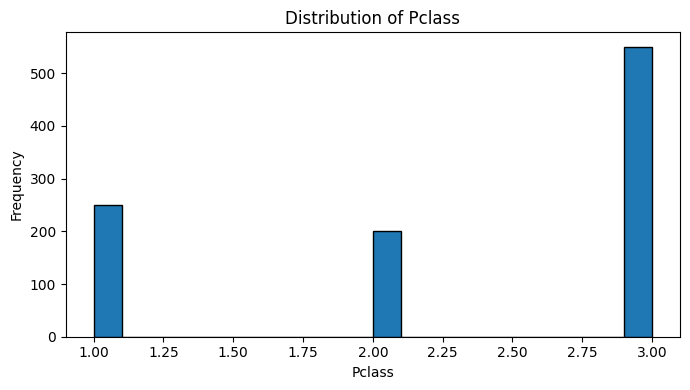

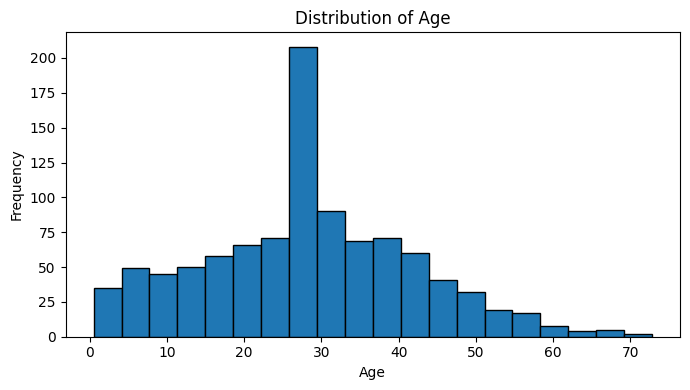

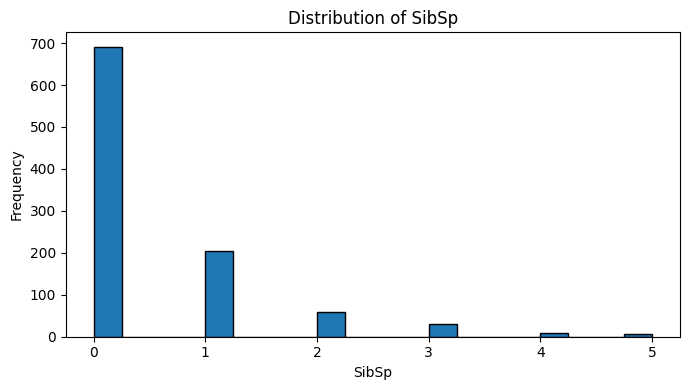

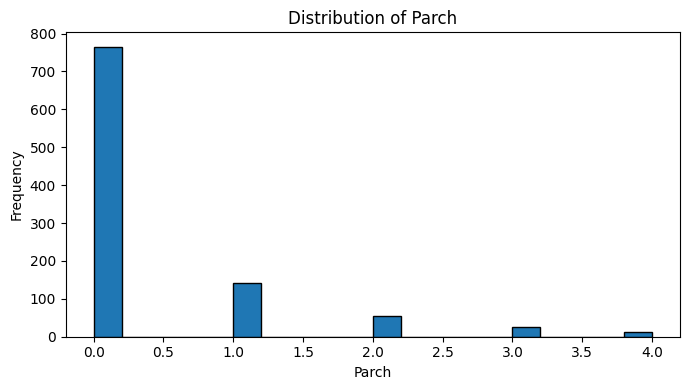

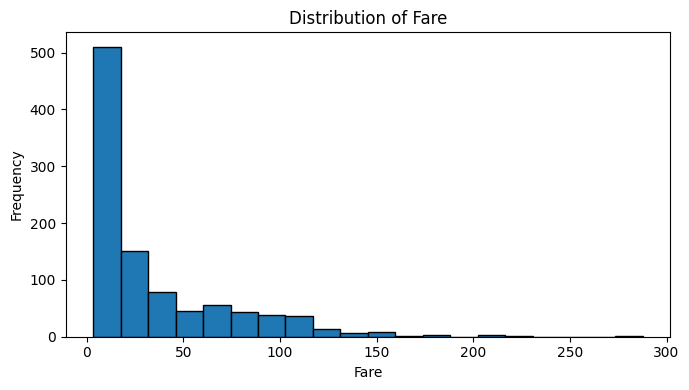


Correlation Matrix:
          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.245334 -0.022332  0.009896  0.046814  0.197042
Pclass   -0.245334  1.000000  0.027084 -0.012789 -0.016148 -0.814959
Age      -0.022332  0.027084  1.000000  0.032397 -0.029033 -0.036590
SibSp     0.009896 -0.012789  0.032397  1.000000 -0.002999 -0.013647
Parch     0.046814 -0.016148 -0.029033 -0.002999  1.000000  0.029240
Fare      0.197042 -0.814959 -0.036590 -0.013647  0.029240  1.000000


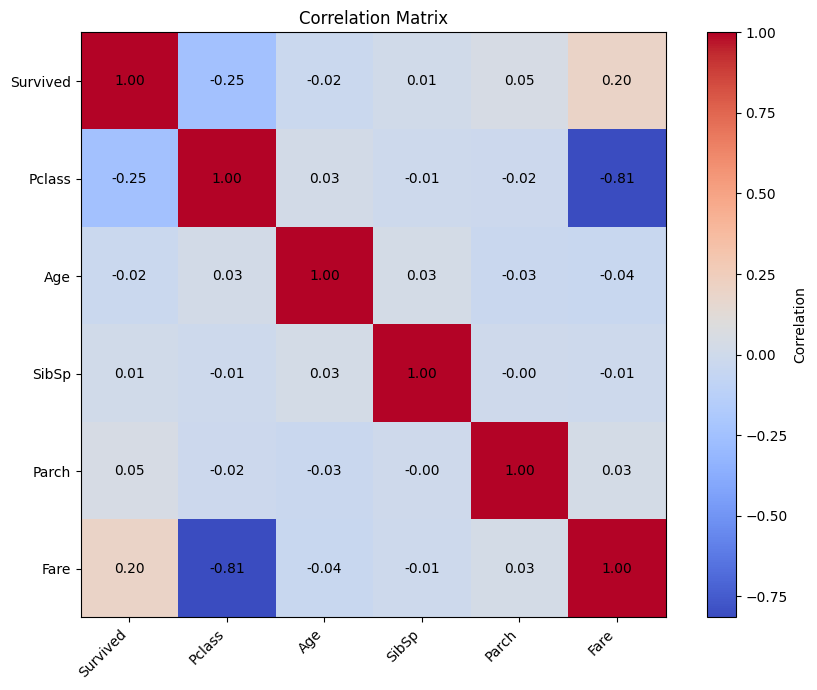

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD DATASET
file_path = "/content/titanic_like_synthetic_dataset.csv"
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# 2. DATA CLEANING

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

if "PassengerId" in numeric_columns:
    numeric_columns.remove("PassengerId")

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Handle missing numerical values using median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Handle missing categorical values using mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# 3. SUMMARY STATISTICS

print("\nSummary Statistics:")
print(df[numeric_columns].describe())

# 4. DISTRIBUTION PLOTS

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=20, edgecolor="black")
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 5. CORRELATION PLOT

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

for i in range(len(correlation)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()